# Classificando Dados

In [1]:
# Para a construção de um modelo de machine learning são necessários dados. 
# Como tarefa inicial, faça a leitura da base de dados de diabetes e realize a divisão dos dados em variáveis explicativas 
# e variável alvo (x e y). A variável alvo é a coluna que quer classificar, contendo a informação se o paciente possui ou não a diabetes. As variáveis explicativas são todas as colunas com exceção da diabetes. 
# A separação dos dados pode ser feita com a seleção de colunas com pandas
import pandas as pd

dados = pd.read_csv(r'C:\Users\Usuario\Documents\Estudos\ALURA\05_Data_Science\raw\diabetes.csv')
X = dados.drop(columns='diabetes')
y = dados['diabetes']

In [2]:
# Uma etapa muito importante em projetos de classificação é a validação dos modelos, 
# para identificar se está havendo a generalização do modelo para dados novos. 
# Realize a divisão dos dados entre treino, validação e teste. 
# Utilize 5% dos dados para teste e com o restante, deixe 25% para validação. 
# No momento da separação, use o parâmetro stratify a partir da variável alvo para manter a proporção dos dados.
from sklearn.model_selection import train_test_split
X, X_teste, y, y_teste = train_test_split(X, y, stratify=y, test_size=0.05, random_state=5)
X_treino, x_validacao, y_treino, y_validacao = train_test_split(X, y, stratify=y, random_state=5)

In [3]:
# A etapa de modelagem de dados consiste em utilizar um algoritmo capaz de identificar padrões nos dados e classificar os valores. 
# A partir do modelo é possível extrair uma taxa de acerto para entender o seu desempenho. 
# Crie 2 modelos utilizando os algoritmos DecisionTreeClassifier e RandomForestClassifer e avalie a acurácia de treino e teste, 
# escolhendo o valor 3 para o parâmetro max_depth do algoritmo DecisionTreeClassifier 
# e valor 2 para o max_depth do algoritmo RandomForestClassifier, 
# para os modelos não se especializarem demais no padrão dos dados de treino
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier()
dtc = DecisionTreeClassifier(max_depth=3)
rfc = RandomForestClassifier(max_depth=2)

dummy.fit(X_treino, y_treino)
dtc.fit(X_treino, y_treino)
rfc.fit(X_treino, y_treino)

print(f'Acurária da DummyClassifier: {dummy.score(X_teste, y_teste)}')
print(f'Acurácia de validação: {dummy.score(x_validacao, y_validacao)}\n')
print(f'Acurária da RandomForestClassifier: {rfc.score(X_teste, y_teste)}')
print(f'Acurácia de validação: {rfc.score(x_validacao, y_validacao)}\n')
print(f'Acurária da DecisionTreeClassifier: {dtc.score(X_teste, y_teste)}')
print(f'Acurácia de validação: {dtc.score(x_validacao, y_validacao)}')

Acurária da DummyClassifier: 0.65
Acurácia de validação: 0.6702127659574468

Acurária da RandomForestClassifier: 0.65
Acurácia de validação: 0.6914893617021277

Acurária da DecisionTreeClassifier: 0.7
Acurácia de validação: 0.776595744680851


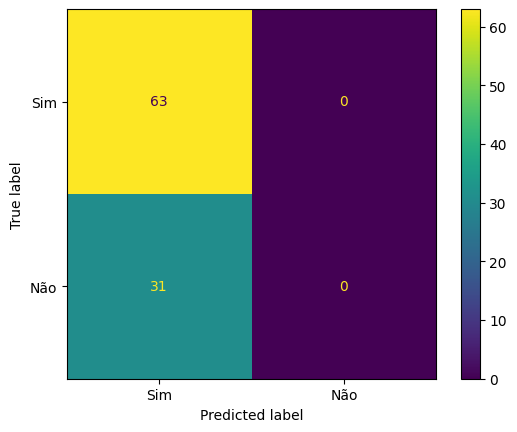

In [4]:
# A taxa de acerto geralmente não fornece informações suficientes para entender o comportamento do modelo. 
# A matriz de confusão é uma ferramenta mais completa, capaz de fornecer os acertos e erros do modelo para cada classe. 
# Construa uma matriz de confusão para cada um dos modelos para avaliar o desempenho da previsão. 
# Para construir a matriz, use o método predict para gerar as previsões dos valores e comparar com os valores reais da base de dados.
from sklearn.metrics import confusion_matrix,  ConfusionMatrixDisplay

y_previsto_dummy = dummy.predict(x_validacao)
matriz_confusao = confusion_matrix(y_validacao, y_previsto_dummy)
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=['Sim', 'Não'])
visualizacao.plot();

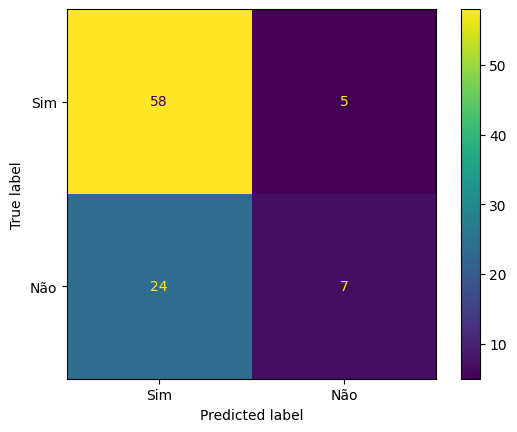

In [5]:
y_previsto_rfc = rfc.predict(x_validacao)
matriz_confusao = confusion_matrix(y_validacao, y_previsto_rfc)
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=['Sim', 'Não'])
visualizacao.plot();

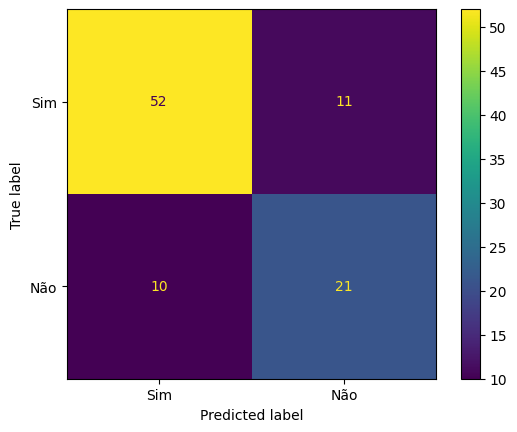

In [6]:
y_previsto_dtc = dtc.predict(x_validacao)
matriz_confusao = confusion_matrix(y_validacao, y_previsto_dtc)
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=['Sim', 'Não'])
visualizacao.plot();

# Métricas e Avaliações

In [7]:
# Para uma avaliação completa de um modelo de classificação, podemos explorar métricas que avaliam a taxa de acerto geral 
# e também para cada classe da variável alvo de forma individual. Extraia as métricas acurácia, recall, precisão e F1-Score 
# dos modelos de classificação gerados no desafio da aula 1. 
# A biblioteca Scikit-Learn possui funções para calcular cada uma das métricas, bastando fazer a importação 
# e utilizar como parâmetros os valores reais e previstos pelo model
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

print('-'*50)
print('DecisionTreeClassifier')
print(f'Precisão: {precision_score(y_validacao, y_previsto_dtc)}')
print(f'Recall: {recall_score(y_validacao, y_previsto_dtc)}')
print(f'F1-Score: {f1_score(y_validacao, y_previsto_dtc)}')
print(f'Acuráricia: {accuracy_score(y_validacao, y_previsto_dtc)}')
print('-'*50)
print('Dummy')
print(f'Precisão: {precision_score(y_validacao, y_previsto_dummy)}')
print(f'Recall: {recall_score(y_validacao, y_previsto_dummy)}')
print(f'F1-Score: {f1_score(y_validacao, y_previsto_dummy)}')
print(f'Acuráricia: {accuracy_score(y_validacao, y_previsto_dummy)}')
print('-'*50)
print('RandomForestClassifier')
print(f'Precisão: {precision_score(y_validacao, y_previsto_rfc)}')
print(f'Recall: {recall_score(y_validacao, y_previsto_rfc)}')
print(f'F1-Score: {f1_score(y_validacao, y_previsto_rfc)}')
print(f'Acuráricia: {accuracy_score(y_validacao, y_previsto_rfc)}')
print('-'*50)

--------------------------------------------------
DecisionTreeClassifier
Precisão: 0.65625
Recall: 0.6774193548387096
F1-Score: 0.6666666666666666
Acuráricia: 0.776595744680851
--------------------------------------------------
Dummy
Precisão: 0.0
Recall: 0.0
F1-Score: 0.0
Acuráricia: 0.6702127659574468
--------------------------------------------------
RandomForestClassifier
Precisão: 0.5833333333333334
Recall: 0.22580645161290322
F1-Score: 0.32558139534883723
Acuráricia: 0.6914893617021277
--------------------------------------------------


c:\Users\Usuario\Documents\Estudos\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


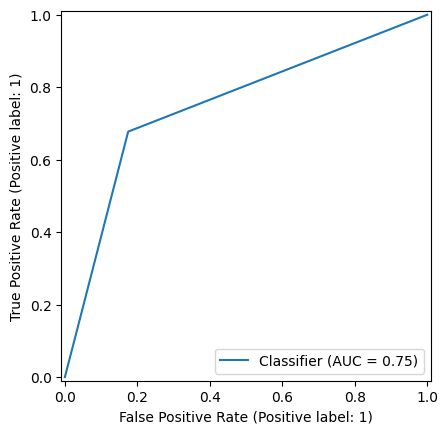

In [8]:
# 2 - Além de métricas numéricas, gráficos podem ser explorados para avaliar o desempenho de um modelo 
# e compreender se ele consegue diferenciar bem uma classe da outra. 
# Obtenha a curva ROC e a métrica AUC dos modelos de classificação gerados no desafio da aula 1, 
# comparando as curvas no mesmo gráfico. A curva ROC pode ser gerada usando o método RocCurveDisplay.from_predictions.
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_validacao, y_previsto_dtc)

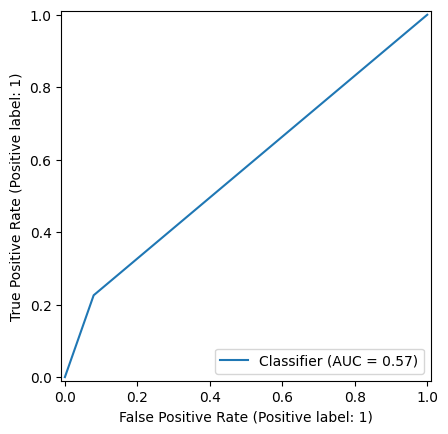

In [9]:
RocCurveDisplay.from_predictions(y_validacao, y_previsto_rfc)

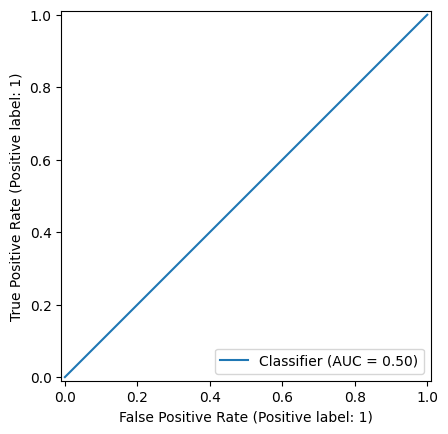

In [10]:
RocCurveDisplay.from_predictions(y_validacao, y_previsto_dummy)

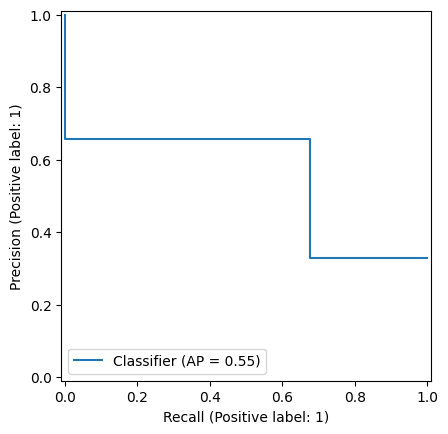

In [11]:
# Além da curva ROC, a curva de precisão x recall pode ser usada para avaliar o desempenho de modelos, 
# sendo mais interessante para dados desbalanceados. Obtenha a curva precisão x recall e a métrica AP dos modelos de classificação 
# gerados no desafio da aula 1, comparando as curvas no mesmo gráfico. 
# A curva precisão x recall pode ser gerada usando o método PrecisionRecallDisplay.from_predictions.
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_predictions(y_validacao, y_previsto_dtc)

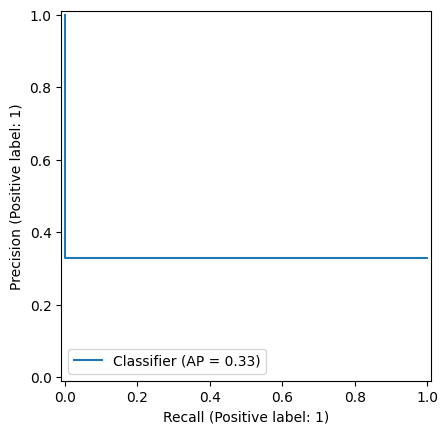

In [12]:
PrecisionRecallDisplay.from_predictions(y_validacao, y_previsto_dummy)

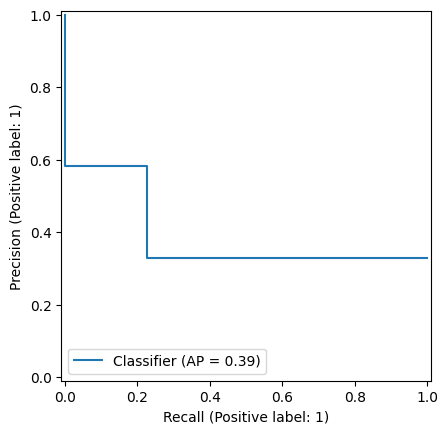

In [13]:
PrecisionRecallDisplay.from_predictions(y_validacao, y_previsto_rfc)

In [14]:
#4 - Um resumo das principais métricas de classificação pode ser muito útil para sumarizar as informações 
# e gerar insights de forma rápida. Gere os relatórios de métricas dos modelos de classificação construídos no desafio da aula 1.
#  O relatório de métricas pode ser gerado a partir da função classification_report da biblioteca Scikit-Learn.
from sklearn.metrics import classification_report
print(classification_report(y_validacao, y_previsto_dummy))
print(classification_report(y_validacao, y_previsto_dtc))
print(classification_report(y_validacao, y_previsto_rfc))

              precision    recall  f1-score   support

           0       0.67      1.00      0.80        63
           1       0.00      0.00      0.00        31

    accuracy                           0.67        94
   macro avg       0.34      0.50      0.40        94
weighted avg       0.45      0.67      0.54        94

              precision    recall  f1-score   support

           0       0.84      0.83      0.83        63
           1       0.66      0.68      0.67        31

    accuracy                           0.78        94
   macro avg       0.75      0.75      0.75        94
weighted avg       0.78      0.78      0.78        94

              precision    recall  f1-score   support

           0       0.71      0.92      0.80        63
           1       0.58      0.23      0.33        31

    accuracy                           0.69        94
   macro avg       0.65      0.57      0.56        94
weighted avg       0.67      0.69      0.64        94



c:\Users\Usuario\Documents\Estudos\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuario\Documents\Estudos\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuario\Documents\Estudos\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

# Validação Cruzada

In [15]:
# 1 - No processo de validação cruzada, são gerados diferentes modelos para cada divisão realizada nos dados 
# e consequentemente diferentes valores de métricas de avaliação. Para encontrar um resultado médio das métricas, 
# pode ser construído um intervalo de confiança a partir da média e desvio padrão das métricas. 
# Crie uma função para calcular o intervalo de confiança dos resultados de uma validação cruzada com 2 desvios padrão. 
# A função precisa de 2 parâmetros: um para receber uma lista com os resultados das métricas da validação cruzada 
# e outro para receber o nome do algoritmo. Para gerar o intervalo de confiança, extraia a média dos resultados da lista e o desvio padrão. 
# O intervalo de confiança deve ser apresentado em um print com o valor mínimo sendo a média subtraída de 2 desvios padrão 
# e o valor máximo sendo a média somada de 2 desvios padrão
def intervalo_conf(resultados, nome_modelo):
    media = resultados.mean()
    desvio_padrao = resultados.std()
    print(f'Intervalo de confiança ({nome_modelo}): [{media - 2*desvio_padrao}, {min(media + 2*desvio_padrao, 1)}]')


In [16]:
# 2 - KFold é a estratégia mais simples de validação cruzada, que permite a divisão aleatória dos dados em k partes, 
# sendo utilizada uma parte para validação e o restante para treinamento do modelo. O processo de criação de modelos 
# é feito novamente até que todas as partes sejam utilizadas como validação. Sabendo disso, avalie o desempenho dos modelos com um intervalo de confiança
# utilizando a validação cruzada com o método KFold, usando 10 partes, com uso do parâmetro n_splits e embaralhando os dados antes da separação 
# com o parâmetro shuffle. Use o método cross_val_score que não retorna o tempo de execução, apenas as métricas
from sklearn.model_selection import cross_val_score, KFold

dtc = DecisionTreeClassifier(max_depth = 3)
rfc = RandomForestClassifier(max_depth = 2)

kf = KFold(n_splits = 10, shuffle = True, random_state = 5)

results_dtc = cross_val_score(dtc, X, y, cv = kf)
results_rf = cross_val_score(rfc, X, y, cv = kf)

intervalo_conf(results_dtc, 'Decision Tree')
intervalo_conf(results_rf, 'Random Forest')

Intervalo de confiança (Decision Tree): [0.5337181765177326, 0.8684155361422958]
Intervalo de confiança (Random Forest): [0.6038552985440709, 0.7699711594929132]


In [17]:
# 3 - No processo de divisão de dados com o KFold aleatório, pode ser que a proporção de cada categoria da variável alvo não seja mantida 
# em cada uma das partes dos dados. Para manter essa proporção em cada uma das partes, podemos utilizar o KFold estratificado, 
# deixando o processo de validação de dados bem mais consistente. Avalie o desempenho dos modelos com um intervalo de confiança 
# utilizando a validação cruzada (cross_val_score) com o método StratifiedKFold, com uso do parâmetro n_splits e embaralhando os dados 
# antes da separação com o parâmetro shuffle e avaliando a métrica F1-Score usando o parâmetro scoring
from sklearn.model_selection import cross_val_score, StratifiedKFold
dtc = DecisionTreeClassifier(max_depth = 3)
rfc = RandomForestClassifier(max_depth = 2)

skf = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 5)

results_dtc = cross_val_score(dtc, X, y, cv = skf, scoring = 'f1')
results_rf = cross_val_score(rfc, X, y, cv = skf, scoring =  'f1')

intervalo_conf(results_dtc, 'Decision Tree')
intervalo_conf(results_rf, 'Random Forest') 

Intervalo de confiança (Decision Tree): [0.2681981750463088, 0.7354166140441551]
Intervalo de confiança (Random Forest): [-0.053915784799075606, 0.737954066778534]


In [18]:
# 4 - Em conjuntos de dados com poucos registros (poucas linhas), as estratégias de separação dos dados para validação podem fazer 
# com que reste pouca informação nos dados de treinamento, fazendo com que o modelo não compreenda bem o padrão dos dados. 
# O LeaveOneOut é uma estratégia para contornar esse problema, utilizando apenas um registro como dado de validação. 
# Avalie o desempenho dos modelos utilizando a validação cruzada (cross_val_score) com o método LeaveOneOut.
from sklearn.model_selection import cross_val_score, LeaveOneOut

dtc = DecisionTreeClassifier(max_depth = 3)
rfc = RandomForestClassifier(max_depth = 2)

loo = LeaveOneOut()

results_dtc = cross_val_score(dtc, X, y, cv = loo)
results_rf = cross_val_score(rfc, X, y, cv = loo)

print(f'Acurácia média (Decision Tree): {results_dtc.mean()}')
print(f'Acurácia média (Random Forest):{results_rf.mean()}') 


Acurácia média (Decision Tree): 0.7085561497326203
Acurácia média (Random Forest):0.6818181818181818


# Balanceamento dos Dados

In [19]:
# 1 - O desbalanceamento dos dados da variável alvo pode fazer com que o modelo fique tendencioso a acertar os padrões de apenas da categoria 
# que tem maior quantidade, tornando necessário em alguns casos um tratamento específico de balanceamento de dados. 
# A etapa inicial é identificar se existe ou não o desbalanceamento de dados na variável alvo. 
# Por conta disso, verifique a proporção de dados da variável alvo do conjunto de dados de diabetes. 
# Essa análise pode ser feita a partir da porcentagem de dados, usando o método value_counts(normalize=True) ou com a utilização de um gráfico de contagem, 
# usando o gráfico countplot da biblioteca seaborn para entender se há um desbalanceamento de dados.
dados['diabetes'].value_counts(normalize = True)


diabetes
0    0.670051
1    0.329949
Name: proportion, dtype: float64

In [ ]:
# 2 - Ao realizar o balanceamento de dados em uma validação cruzada, é necessário utilizar um pipeline, para que os dados de validação não sejam balanceados, 
# se mantendo no padrão dos dados do mundo real. Utilize um pipeline contendo ajuste do modelo e o balanceamento dos dados usando o oversampling com SMOTE, 
# obtendo a média do F1-Score de uma validação cruzada com StratifiedKFold.
from imblearn.pipeline import Pipeline as imbpipeline
from imblearn.over_sampling import SMOTE

dtc = DecisionTreeClassifier(max_depth = 3)
pipeline = imbpipeline([('oversample', SMOTE()), ('arvore', dtc)])
skf = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 5)
resultado_dtc = cross_val_score(pipeline, X, y, cv = skf, scoring = 'f1')
print(f'F1 (Decision Tree):{resultado_dtc.mean()}')

rf = RandomForestClassifier(max_depth = 2)
pipeline = imbpipeline([('oversample', SMOTE()), ('random_forest', rf)])
skf = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 5)
resultado_rf = cross_val_score(pipeline, X, y, cv = skf, scoring = 'f1')
print(f'F1 (Random Forest):{resultado_rf.mean()}') 

F1 (Decision Tree):0.5660988534517946
F1 (Random Forest):0.6168481478061567


In [22]:
# 3 - Além do oversampling, é possível utilizar a estratégia de undersampling para fazer o balanceamento dos dados. 
# Apesar de serem estratégias distintas, ambas necessitam de um pipeline por se tratar de balanceamento de dados em uma validação cruzada. 
# Utilize um pipeline contendo ajuste do modelo e o balanceamento dos dados usando o undersampling com NearMiss na sua versão 3, 
# obtendo a média do F1-Score de uma validação cruzada com StratifiedKFold.
from imblearn.under_sampling import NearMiss
from imblearn.pipeline import Pipeline as imbpipeline

dtc = DecisionTreeClassifier(max_depth = 3)
pipeline = imbpipeline([('undersample', NearMiss(version = 3)), ('arvore', dtc)])
skf = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 5)
resultado_dtc = cross_val_score(pipeline, X, y, cv = skf, scoring = 'f1')
print(f'F1 (Decision Tree):{resultado_dtc.mean()}') 

rf = RandomForestClassifier(max_depth = 2)
pipeline = imbpipeline([('undersample', NearMiss(version = 3)), ('random_forest', rf)])
skf = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 5)
resultado_rf = cross_val_score(pipeline, X, y, cv = skf, scoring = 'f1')
print(f'F1 (Random Forest):{resultado_rf.mean()}')

F1 (Decision Tree):0.5460263484053807
F1 (Random Forest):0.6128457535724013


              precision    recall  f1-score   support

           0       0.80      0.62      0.70        13
           1       0.50      0.71      0.59         7

    accuracy                           0.65        20
   macro avg       0.65      0.66      0.64        20
weighted avg       0.70      0.65      0.66        20



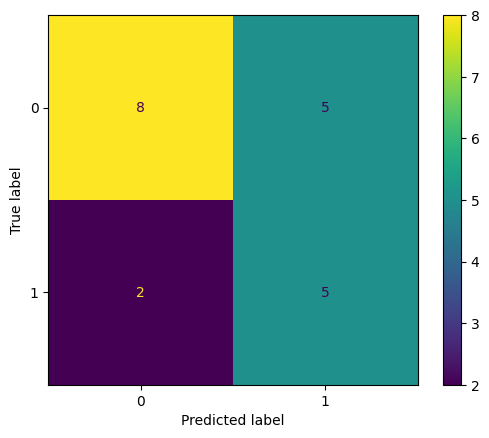

In [23]:
# 4 - Após realizar diversas análises e aprimorar o desempenho dos modelos, chega a etapa final, que consiste em selecionar o modelo com melhor desempenho 
# e fazer a avaliação final em um conjunto de dados de teste, que não foi visto durante o processo de treinamento e validação. 
# Escolha o modelo que obteve o melhor desempenho ao comparar as estratégias de oversampling e undersampling 
# e treine um modelo usando todos os dados com a melhor estratégia. Realize a avaliação do modelo usando os dados de teste que foram separados no início dos desafios, 
# obtendo o relatório de métricas e matriz de confusão.
undersample = NearMiss(version = 3)
X_balanceado, y_balanceado = undersample.fit_resample(X, y)

modelo = RandomForestClassifier(max_depth = 2)
modelo.fit(X_balanceado, y_balanceado)
y_previsto = modelo.predict(X_teste)

print(classification_report(y_teste, y_previsto))
ConfusionMatrixDisplay.from_predictions(y_teste, y_previsto);